In [1]:
# Imports necesarios
import random
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import scipy as sp
from greedy import greedy_monedas
from util import time_algorithm

# Set seed for reproducibility
random.seed(12345)
np.random.seed(12345)
sns.set_theme()


In [2]:
# Tamaños del array
x = np.linspace(1000, 1_000_000, 20).astype(int)

# Generador de monedas aleatorias
def get_random_cant_monedas(s):
    return [random.randint(1, 50) for _ in range(s)]

# Medimos los tiempos de ejecución
results = time_algorithm(greedy_monedas, x, lambda s: [get_random_cant_monedas(s)])
print(results)


{np.int64(1000): 0.0003985881805419922, np.int64(53578): 0.022687315940856934, np.int64(106157): 0.03890094757080078, np.int64(158736): 0.04640061855316162, np.int64(211315): 0.06914863586425782, np.int64(263894): 0.08953056335449219, np.int64(316473): 0.1123420000076294, np.int64(369052): 0.10240809917449951, np.int64(421631): 0.12747223377227784, np.int64(474210): 0.15550990104675294, np.int64(526789): 0.14912168979644774, np.int64(579368): 0.15317387580871583, np.int64(631947): 0.17677707672119142, np.int64(684526): 0.1886540174484253, np.int64(737105): 0.19320204257965087, np.int64(789684): 0.23048019409179688, np.int64(842263): 0.23148083686828613, np.int64(894842): 0.26025981903076173, np.int64(947421): 0.26379549503326416, np.int64(1000000): 0.3710934162139893}


Text(0, 0.5, 'Tiempo de ejecución (s)')

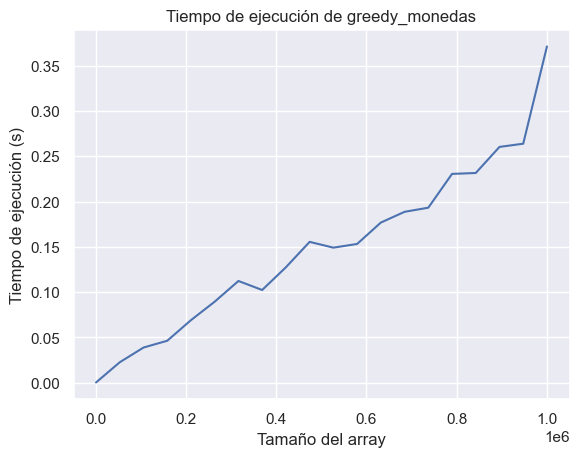

In [3]:
# Graficamos los resultados
fig, ax = plt.subplots()
ax.plot(x, [results[n] for n in x], 'b-', label="Medición")  # Datos medidos
ax.set_title('Tiempo de ejecución de greedy_monedas')
ax.set_xlabel('Tamaño del array')
ax.set_ylabel('Tiempo de ejecución (s)')


In [4]:
# Ajuste O(n log n)
f_nlogn = lambda x, c1, c2: c1 * x * np.log(x) + c2
c_nlogn, _ = sp.optimize.curve_fit(f_nlogn, x, [results[n] for n in x])
ax.plot(x, [f_nlogn(n, *c_nlogn) for n in x], 'r--', label="Ajuste O(n log n)")

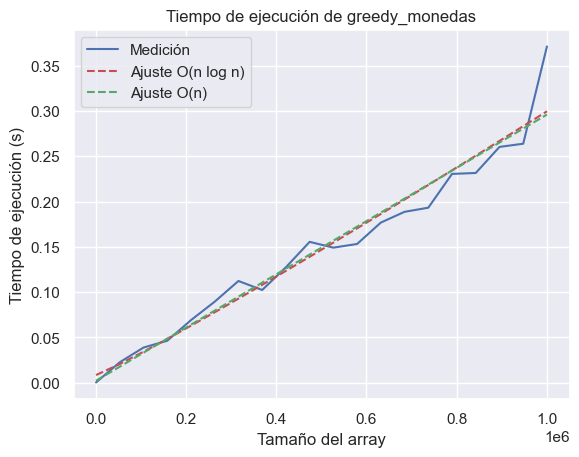

In [5]:
# Ajuste O(n)
f_n = lambda x, c1, c2: c1 * x + c2
c_n, _ = sp.optimize.curve_fit(f_n, x, [results[n] for n in x])
ax.plot(x, [f_n(n, *c_n) for n in x], 'g--', label="Ajuste O(n)")

# Agregar leyenda y mostrar
ax.legend()
fig

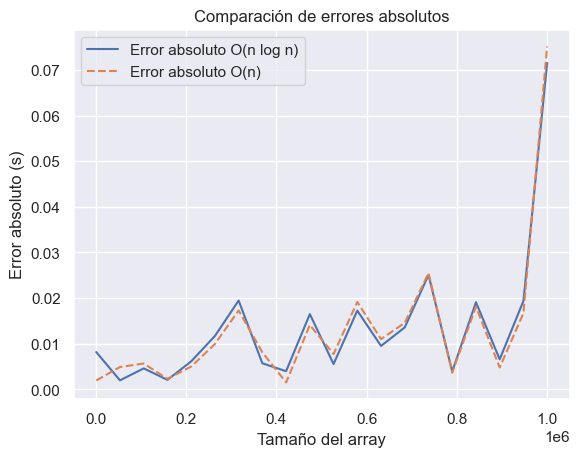

In [8]:
# Graficar los errores absolutos de los ajustes
fig, ax = plt.subplots()

# Errores absolutos para O(n log n) y O(n)
errors_nlogn = [np.abs(f_nlogn(n, *c_nlogn) - results[n]) for n in x]
errors_n = [np.abs(f_n(n, *c_n) - results[n]) for n in x]

# Graficar
ax.plot(x, errors_nlogn, label="Error absoluto O(n log n)")
ax.plot(x, errors_n, label="Error absoluto O(n)", linestyle='--')

ax.set_title("Comparación de errores absolutos")
ax.set_xlabel("Tamaño del array")
ax.set_ylabel("Error absoluto (s)")
ax.legend()

In [7]:
# Imprimir parámetros ajustados y errores
print(f"Ajuste O(n log n): c_1 = {c_nlogn[0]}, c_2 = {c_nlogn[1]}")
r_nlogn = np.sum((f_nlogn(x, *c_nlogn) - [results[n] for n in x])**2)
print(f"Error cuadrático total (O(n log n)): {r_nlogn}")

print(f"Ajuste O(n): c_1 = {c_n[0]}, c_2 = {c_n[1]}")
r_n = np.sum((f_n(x, *c_n) - [results[n] for n in x])**2)
print(f"Error cuadrático total (O(n)): {r_n}")

# Comparar los errores
if r_nlogn < r_n:
    print(f"El ajuste O(n log n) es mejor con un menor error cuadrático total: {r_nlogn}")
else:
    print(f"El ajuste O(n) es mejor con un menor error cuadrático total: {r_n}")


Ajuste O(n log n): c_1 = 2.1072480747613685e-08, c_2 = 0.008420498625713979
Error cuadrático total (O(n log n)): 0.008118315683460768
Ajuste O(n): c_1 = 2.939065930667798e-07, c_2 = 0.002041750083919548
Error cuadrático total (O(n)): 0.008453017404278576
El ajuste O(n log n) es mejor con un menor error cuadrático total: 0.008118315683460768
